## Task 1 : Data Collection & Dataset Understanding
### Goal:
- Collect or load a dataset and understand its structure.
Key Requirements:
- Identify columns and data types
- Understand dataset size and features
- Describe what the data represents
### Key Skills:
- Data understanding, exploratory thinking

In [215]:
#import libraries
import pandas as pd
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [216]:
data = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
print("Dataset Shape:")
print(data.shape)

Dataset Shape:
(374, 13)


In [217]:
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [218]:
data.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [219]:
data.dtypes

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

In [220]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


## Task 2: Data Cleaning & Preprocessing
### Goal:
- Prepare the dataset for analysis by cleaning and organizing data.
### Key Requirements:
- Handle missing values.
- Remove duplicates.
- Format data correctly.
### Key Skills:
- Data preprocessing, data quality management.

In [221]:
print("Missing Values:")
data.isnull().sum().sort_values(ascending=False)

Missing Values:


Sleep Disorder             219
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
dtype: int64

In [222]:
print("Basic Statistics:")
data.describe()

Basic Statistics:


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [223]:
# Duplicates
print("Duplicates:", data.duplicated().sum())

Duplicates: 0


In [224]:
# Missing values
print("Missing Values:")
data.isnull().sum().sort_values(ascending=False)

Missing Values:


Sleep Disorder             219
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
dtype: int64

In [225]:
# Filling missing sleep disorder values, NaN means no disorder in this dataset
data['Sleep Disorder'] = data['Sleep Disorder'].fillna('Healthy')

In [226]:
print("Missing Values After:")
data.isnull().sum().sort_values(ascending=False)

Missing Values After:


Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64

In [227]:
bp_split = data['Blood Pressure'].str.split('/', expand=True)
data['Systolic_BP'] = bp_split[0].astype(int)
data['Diastolic_BP'] = bp_split[1].astype(int)
# Drop original column
data.drop('Blood Pressure', axis=1, inplace=True)

In [228]:
le = LabelEncoder()
data['Sleep Disorder Encoded'] = le.fit_transform(data['Sleep Disorder'])

In [229]:
numerical_cols = data.select_dtypes(include=['number']).columns
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data[col] = data[col].astype('category')

In [230]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Person ID                374 non-null    int64   
 1   Gender                   374 non-null    category
 2   Age                      374 non-null    int64   
 3   Occupation               374 non-null    category
 4   Sleep Duration           374 non-null    float64 
 5   Quality of Sleep         374 non-null    int64   
 6   Physical Activity Level  374 non-null    int64   
 7   Stress Level             374 non-null    int64   
 8   BMI Category             374 non-null    category
 9   Heart Rate               374 non-null    int64   
 10  Daily Steps              374 non-null    int64   
 11  Sleep Disorder           374 non-null    category
 12  Systolic_BP              374 non-null    int32   
 13  Diastolic_BP             374 non-null    int32   
 14  Sleep Diso

## Task 3: Exploratory Data Analysis (EDA)
### Goal:
- Analyze the dataset to discover patterns and trends.
### Key Requirements:
- Calculate basic statistics.
- Identify trends and outliers.
- Summarize findings.
### Key Skills:
- Statistical thinking, data analysis.

In [231]:
data.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP,Sleep Disorder Encoded
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920,128.553476,84.649733,0.622995
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679,7.748118,6.161611,0.808537
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,115.000000,75.000000,0.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000,125.000000,80.000000,0.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,130.000000,85.000000,0.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000,135.000000,90.000000,1.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000,142.000000,95.000000,2.000000


In [232]:
# correlation matrix
correlation = data.corr(numeric_only=True)
print("Correlation Matrix:")
correlation

Correlation Matrix:


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP,Sleep Disorder Encoded
Person ID,1.000000,0.990516,0.296305,0.431612,0.149882,-0.394287,-0.225467,0.043844,0.611551,0.590670,0.476492
Age,0.990516,1.000000,0.344709,0.473734,0.178993,-0.422344,-0.225606,0.057973,0.605878,0.593839,0.487832
Sleep Duration,0.296305,0.344709,1.000000,0.883213,0.212360,-0.811023,-0.516455,-0.039533,-0.180406,-0.166570,-0.239109
Quality of Sleep,0.431612,0.473734,0.883213,1.000000,0.192896,-0.898752,-0.659865,0.016791,-0.121632,-0.110151,-0.213003
Physical Activity Level,0.149882,0.178993,0.212360,0.192896,1.000000,-0.034134,0.136971,0.772723,0.265416,0.382651,0.236560
Stress Level,-0.394287,-0.422344,-0.811023,-0.898752,-0.034134,1.000000,0.670026,0.186829,0.102818,0.091811,0.151893
Heart Rate,-0.225467,-0.225606,-0.516455,-0.659865,0.136971,0.670026,1.000000,-0.030309,0.294143,0.271092,0.384343
Daily Steps,0.043844,0.057973,-0.039533,0.016791,0.772723,0.186829,-0.030309,1.000000,0.103342,0.241986,0.112053
Systolic_BP,0.611551,0.605878,-0.180406,-0.121632,0.265416,0.102818,0.294143,0.103342,1.000000,0.972885,0.730103
Diastolic_BP,0.590670,0.593839,-0.166570,-0.110151,0.382651,0.091811,0.271092,0.241986,0.972885,1.000000,0.768796


In [233]:
# Identify outliers 
z_scores = np.abs(zscore(data[numerical_cols]))
outliers = (z_scores > 3).sum(axis=0)
print("Outliers per column:\n", outliers)

Outliers per column:
 Person ID                  0
Age                        0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
Heart Rate                 9
Daily Steps                0
Systolic_BP                0
Diastolic_BP               0
Sleep Disorder Encoded     0
dtype: int64


In [234]:
data.head(3)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP,Sleep Disorder Encoded
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,Healthy,126,83,0
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,125,80,0
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,125,80,0


In [235]:
# Average Sleep Duration
avg_sleep = data['Sleep Duration'].mean()
print(f"Average Sleep Duration: {avg_sleep:.2f} hours")

Average Sleep Duration: 7.13 hours


In [236]:
data['Sleep Disorder'].value_counts()

Sleep Disorder
Healthy        219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [237]:
data['BMI Category'].value_counts()

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

In [238]:
data['Occupation'].value_counts()

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

In [239]:
data['Gender'].value_counts()

Gender
Male      189
Female    185
Name: count, dtype: int64

## Task 4: Data Visualization 
### Goal:
- Create visual representations to communicate insights clearly.
### Key Requirements:
- Create charts and graphs.
- Choose appropriate visual types.
- Highlight key insights.
### Key Skills:
- Data visualization, storytelling with data

In [240]:
# visualization settings
sns.set_theme(style="whitegrid",palette="pastel")
plt.rcParams['figure.figsize'] = (8, 5)

### Correlation heatmap

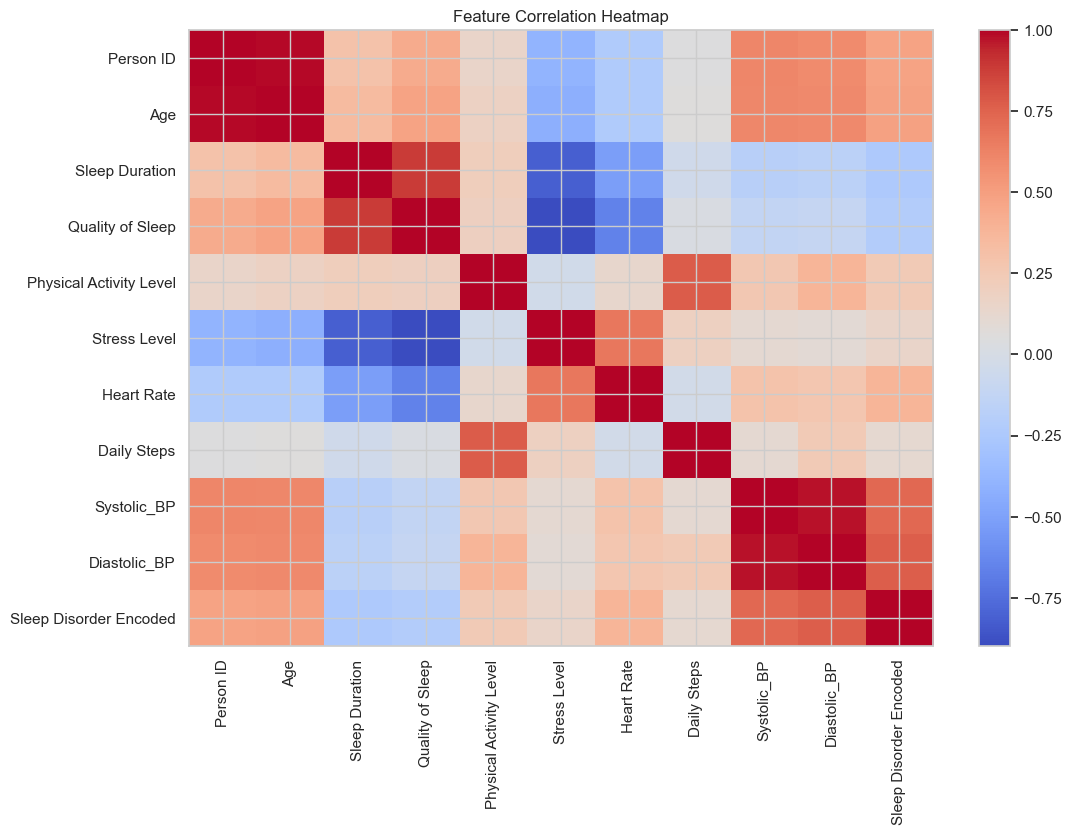

In [241]:
plt.figure(figsize=(12,8))
plt.imshow(correlation, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title('Feature Correlation Heatmap')
plt.show()

### Quality of Sleep Distribution

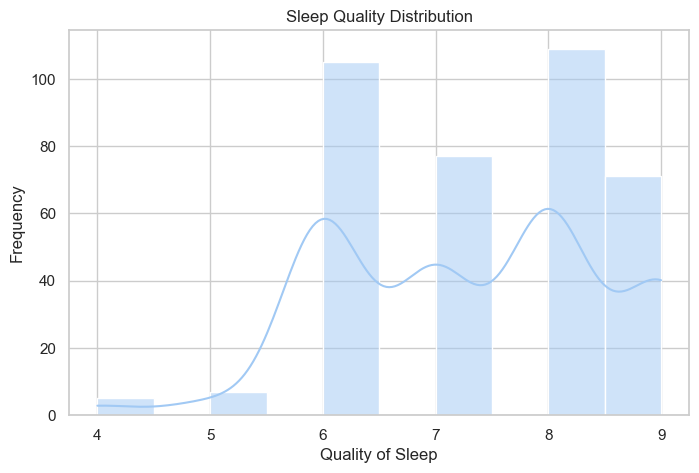

In [242]:
plt.figure()
sns.histplot(data['Quality of Sleep'], bins=10, kde=True)
plt.xlabel('Quality of Sleep')
plt.ylabel('Frequency')
plt.title('Sleep Quality Distribution')
plt.show()

### Daily Steps vs Sleep Quality

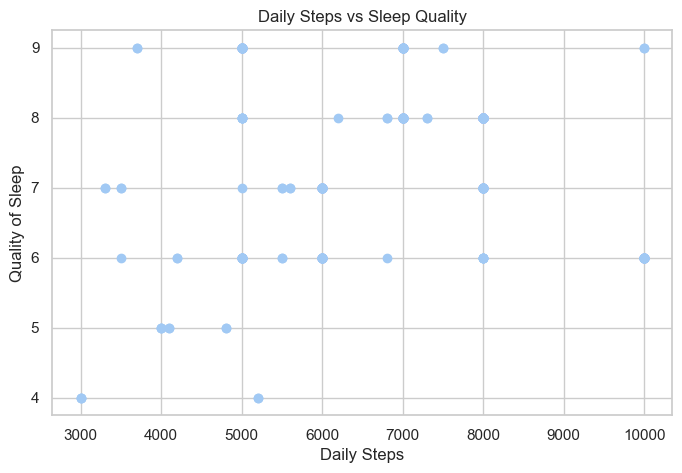

In [243]:
plt.figure()
plt.scatter(data['Daily Steps'], data['Quality of Sleep'])
plt.xlabel('Daily Steps')
plt.ylabel('Quality of Sleep')
plt.title('Daily Steps vs Sleep Quality')
plt.show()

### Sleep Quality vs Stress Level

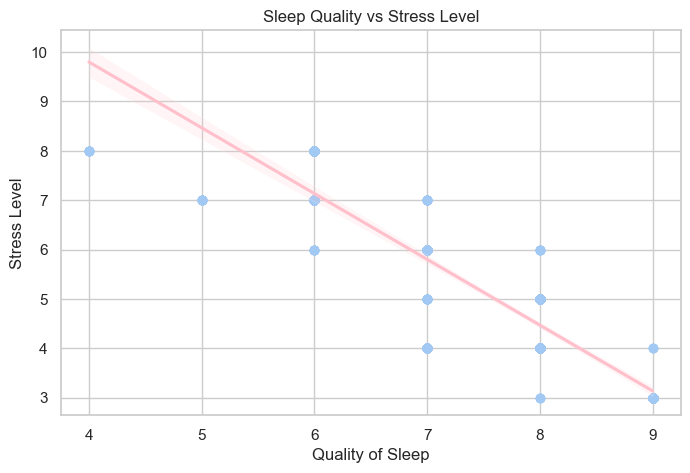

In [244]:
plt.figure()
plt.scatter(data['Quality of Sleep'], data['Stress Level'])
sns.regplot(x='Quality of Sleep', y='Stress Level', data=data, scatter_kws={'alpha':0.5}, line_kws={'color':'pink'})
plt.xlabel('Quality of Sleep')
plt.ylabel('Stress Level')
plt.title('Sleep Quality vs Stress Level')
plt.show()

### Sleep Duration Boxplot

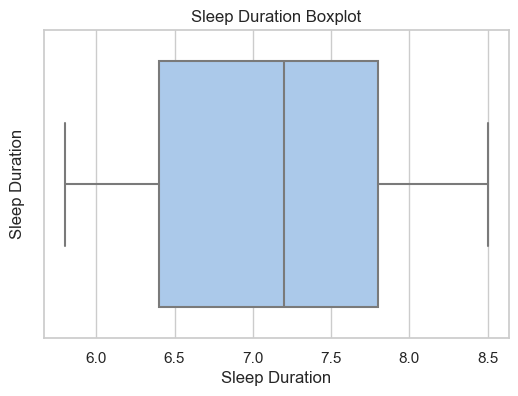

In [245]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Sleep Duration', data=data)
plt.ylabel('Sleep Duration')
plt.title('Sleep Duration Boxplot')
plt.show()

### Stress Level Boxplot

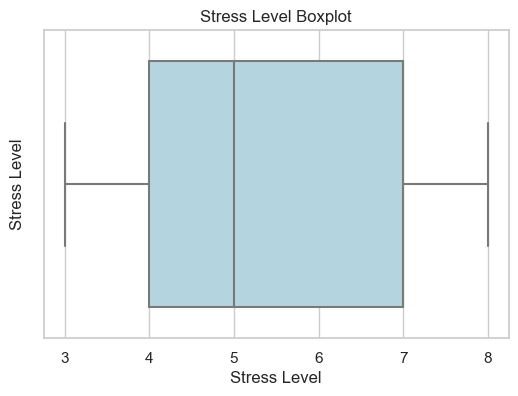

In [246]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Stress Level', data=data, color='lightblue')
plt.ylabel('Stress Level')
plt.title('Stress Level Boxplot')
plt.show()

### Quality of Sleep by Gender

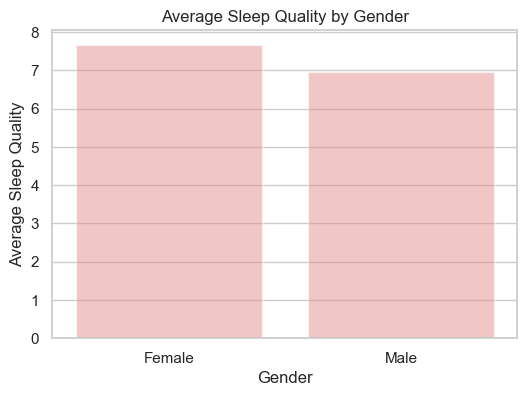

In [247]:
gender_sleep = data.groupby('Gender')['Quality of Sleep'].mean()
plt.figure(figsize=(6, 4))
sns.barplot(x=gender_sleep.index.astype(str), y=gender_sleep.values, alpha=0.5, color='lightcoral')
plt.xlabel('Gender')
plt.ylabel('Average Sleep Quality')
plt.title('Average Sleep Quality by Gender')
plt.show()

### FEATURE IMPORTANCE STYLE PREVIEW

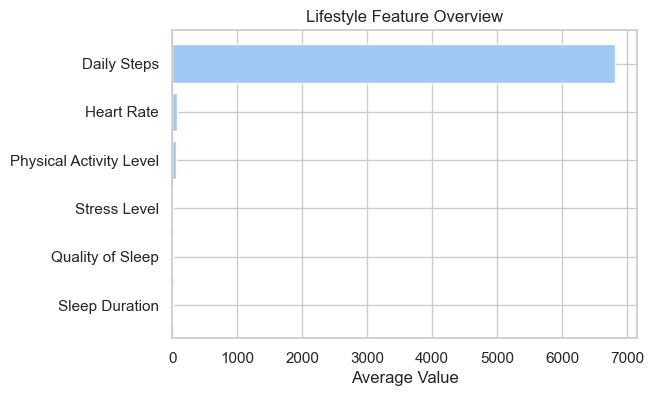

In [248]:
numeric_cols = ['Sleep Duration','Quality of Sleep','Stress Level','Physical Activity Level','Heart Rate','Daily Steps']
feature_means = data[numeric_cols].mean()
plt.figure(figsize=(6,4))
plt.barh(feature_means.index, feature_means.values)
plt.xlabel('Average Value')
plt.title('Lifestyle Feature Overview')
plt.show()

### Sleep Quality Category Counts

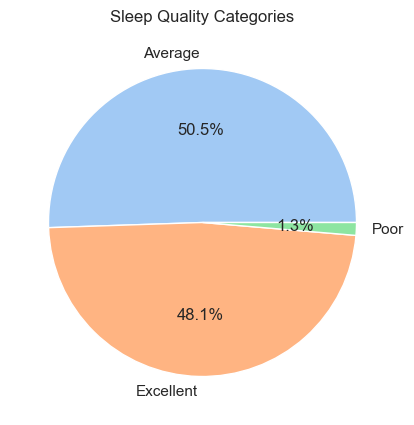

In [249]:
sleep_quality_bins = pd.cut(data['Quality of Sleep'],bins=[0, 4, 7, 10],labels=['Poor', 'Average', 'Excellent'])
quality_counts = sleep_quality_bins.value_counts()
plt.figure(figsize=(8,5))
plt.pie(quality_counts,labels=quality_counts.index,autopct='%1.1f%%')
plt.title('Sleep Quality Categories')
plt.show()

### Age Distribution

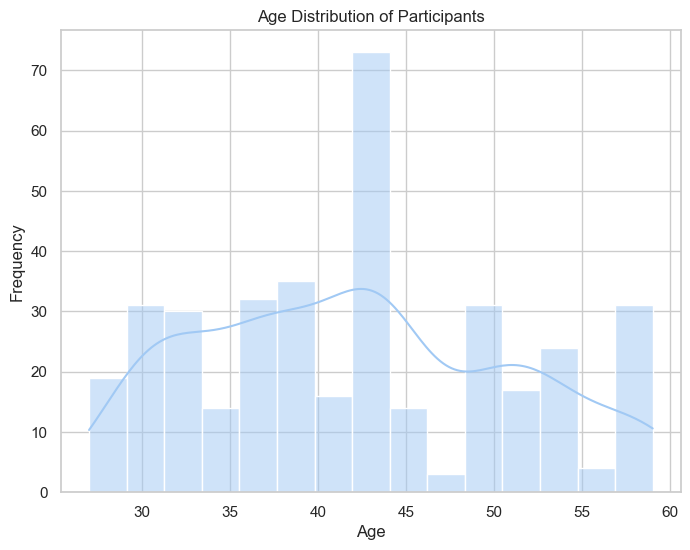

In [250]:
plt.figure(figsize=(8,6))
sns.histplot(data['Age'], bins=15, kde=True)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of Participants')
plt.show()

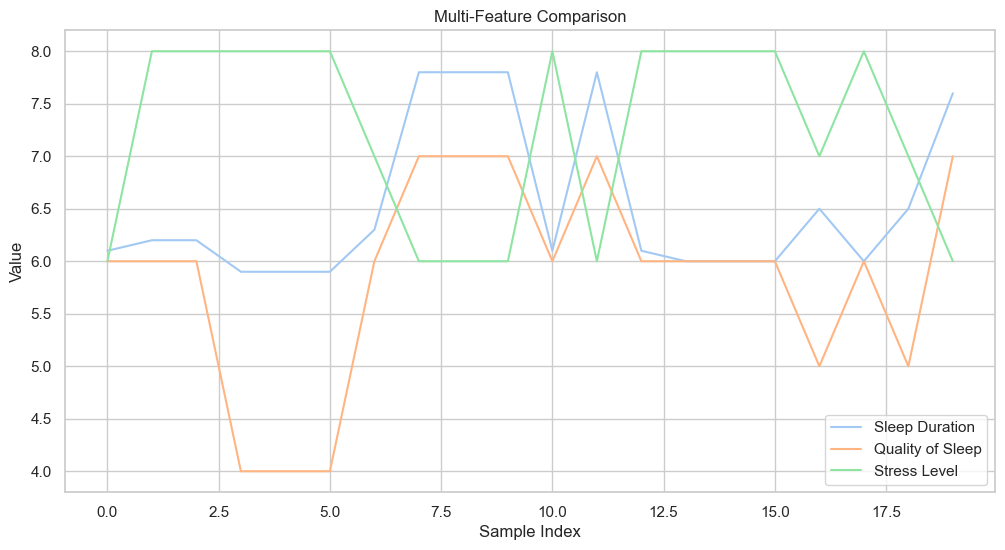

In [251]:
comparison_df = data[['Sleep Duration','Quality of Sleep','Stress Level']].head(20)
plt.figure(figsize=(12,6))
for column in comparison_df.columns:
    plt.plot(comparison_df.index, comparison_df[column], label=column)
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('Multi-Feature Comparison')
plt.legend()
plt.grid(True)
plt.show()

### Sleep duration category analysis

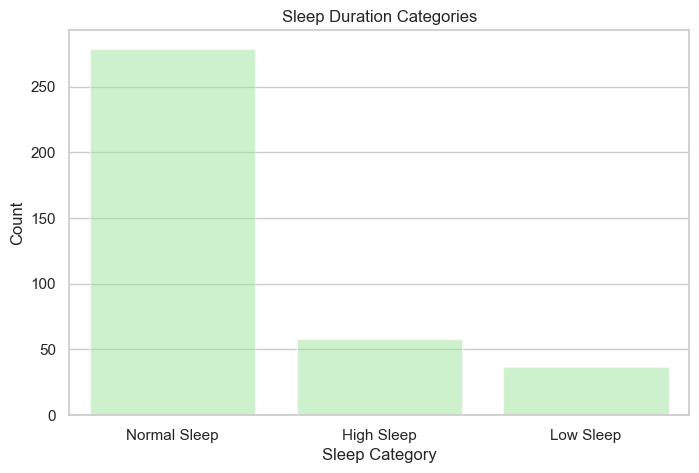

In [252]:
sleep_category = pd.cut(data['Sleep Duration'],bins=[0,6,8,12],labels=['Low Sleep','Normal Sleep','High Sleep'])
sleep_category_counts = sleep_category.value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=sleep_category_counts.index.astype(str), y=sleep_category_counts.values, alpha=0.5, color='lightgreen')
plt.xlabel('Sleep Category')
plt.ylabel('Count')
plt.title('Sleep Duration Categories')
plt.show()

### Gender Distribution Across BMI Categories

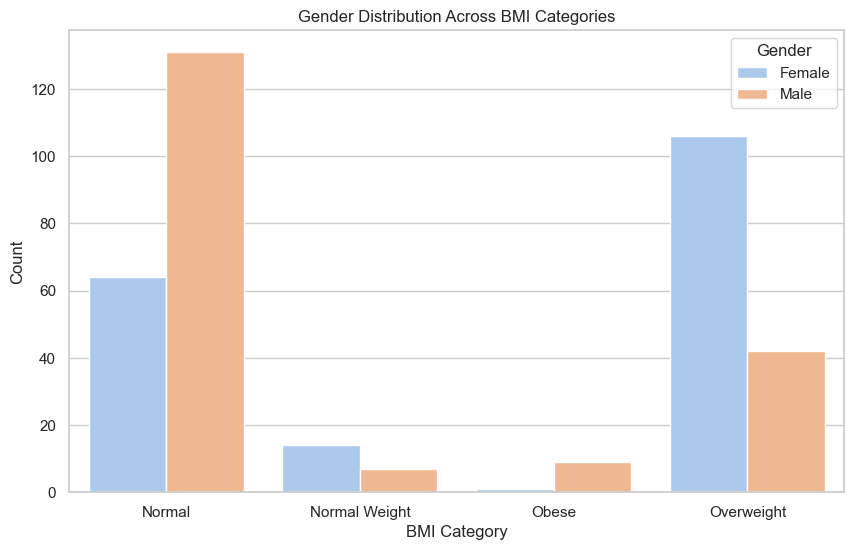

In [253]:
plt.figure(figsize=(10,6))
sns.countplot(data=data,x='BMI Category',hue='Gender')
plt.title('Gender Distribution Across BMI Categories')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()

### Gender Distribution Across Sleep Disorders

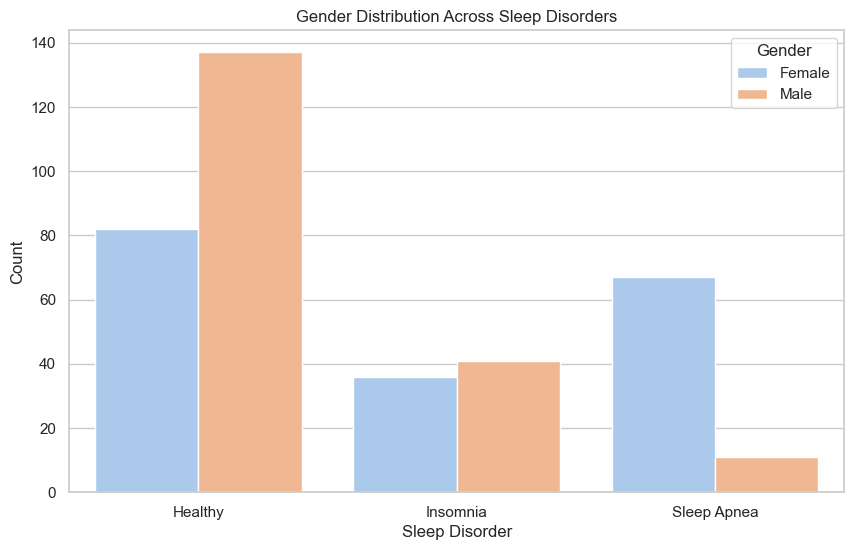

In [254]:
plt.figure(figsize=(10,6))
sns.countplot(data=data,x='Sleep Disorder',hue='Gender')
plt.title('Gender Distribution Across Sleep Disorders')
plt.xlabel('Sleep Disorder')
plt.ylabel('Count')
plt.show()

### Age vs Sleep Disorder Trend

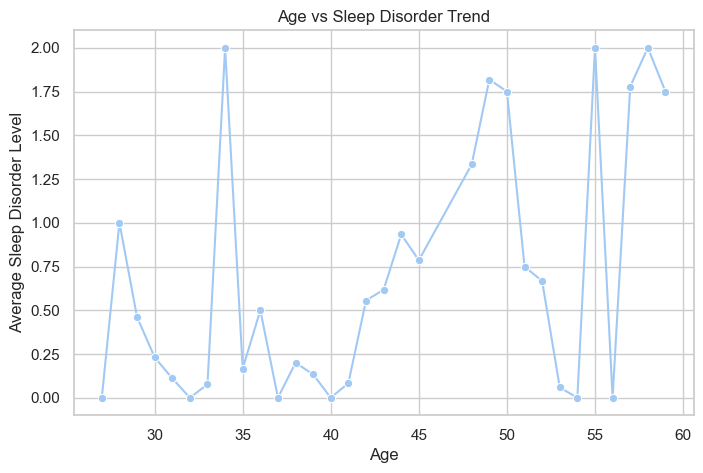

In [255]:
age_sleep = (data.groupby('Age')['Sleep Disorder Encoded'].mean().reset_index())
plt.figure(figsize=(8,5))
sns.lineplot(data=age_sleep,x='Age',y='Sleep Disorder Encoded',marker='o')
plt.title('Age vs Sleep Disorder Trend')
plt.xlabel('Age')
plt.ylabel('Average Sleep Disorder Level')
plt.show()

### Heart Rate vs Sleep Disorder Trend

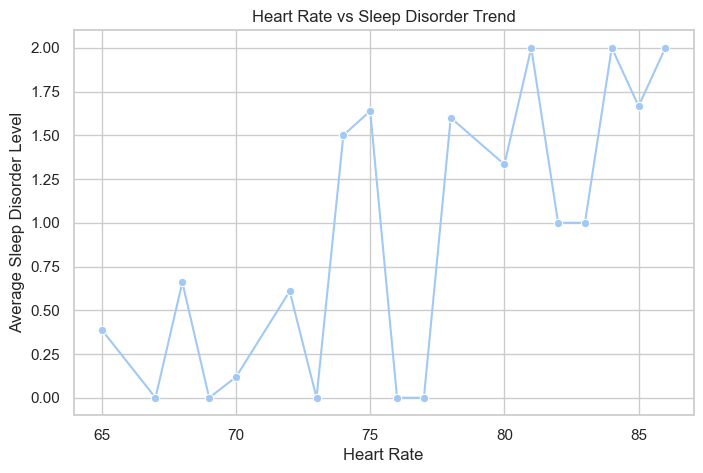

In [256]:
heart_sleep = (data.groupby('Heart Rate')['Sleep Disorder Encoded'].mean().reset_index())
plt.figure(figsize=(8,5))
sns.lineplot(data=heart_sleep,x='Heart Rate',y='Sleep Disorder Encoded',marker='o')
plt.title('Heart Rate vs Sleep Disorder Trend')
plt.xlabel('Heart Rate')
plt.ylabel('Average Sleep Disorder Level')
plt.show()

In [257]:
data.head(3)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP,Sleep Disorder Encoded
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,Healthy,126,83,0
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,125,80,0
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,125,80,0


In [ ]:
data.to_csv('data/data_preprocessed.csv',index=False)